# **Algoritmos de Monte Carlo e Cadeias de Markov - PESC/COPPE/UFRJ - 2026/1**
## **Projeto Final — [TÍTULO]**
### **Prof. Daniel Ratton Figueiredo**
#### **Roberto Leonie Ferreira Moreira (DRE: 126232985)**


## 1. Importando dependências e definindo parâmetros de plotagem

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from tqdm import tqdm

plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Definição do modelo S-I-R
a partir dos hiperparâmetros $\beta$ e $\gamma$, assim como um instante de tempo $t$, dados sintéticos $y_t, 1 < t < T$ e população de $N$ indivíduos inicialmente suscetíveis ao patógeno.

In [49]:
def sir_model(t, y, beta, gamma, N) :
  S, I, R = y
  dS_dt = -(beta * I * S) / N
  dI_dt = (beta * I * S) / N - (gamma * I)
  dR_dt = gamma * I

  return [dS_dt, dI_dt, dR_dt]

## 3. Gerando dados sintéticos (+ ruído)
configurando número $N$ de indivíduos, desvio padrão $\sigma$ — a intensidade do ruído gaussiano —, intervalo de tempo de observação `observation_time` de $[0, T]$, definindo $T+1$ pontos através de `eval_time`. Além disso, para as condições iniciais da epidemia, sejam

*   $I_0 = 1$ (um infectado)
*   $R_0 = 0$ (zero recuperados; não confundir com o número básico de reprodução)
*   $S_0 = N - (I_0 + R_0)$ (praticamente toda a população inicialmente suscetível).

Além disso, sejam `real_beta` e `real_gamma` os reais hiperparâmetros $\beta$ e $\gamma$ que desejamos predizer.




In [50]:
# definindo uma populacao $N$ de 1 milhao,
# real_beta=0.3 e real_gamma=0.1
N = 1_000_000
real_beta = 0.3
real_gamma = 0.1

In [51]:
# para parametros observados em:
# https://people.wku.edu/lily.popova.zhuhadar/
def initial_conditions(N,
                       real_beta,
                       real_gamma,
                       I_0=1,
                       R_0=0,
                       ) :
    S_0 = N - (I_0 + R_0)
    y_0 = [S_0, I_0, R_0]

    return y_0

In [52]:
# definindo um intervalo de tempo
stop = 100
observation_time = (0, stop)
eval_time = np.linspace(0, stop, stop + 1)

In [53]:
# resolvendo a EDO real
def ode_solver(N, real_beta, real_gamma) :
  y_0 = initial_conditions(N, real_beta, real_gamma)

  solver = solve_ivp(sir_model,
                     observation_time,
                     y_0, args=(real_beta, real_gamma, N),
                     t_eval=eval_time)
  I_real = solver.y[1]

  return I_real

In [54]:
def gaussian_noise(sigma, seed=42) :
  I_real = ode_solver(N, real_beta, real_gamma)

  # std_dev = desvio padrao (sigma)
  np.random.seed(seed)
  Y = I_real + np.random.normal(0, sigma, size=len(eval_time))

  return Y, I_real, eval_time


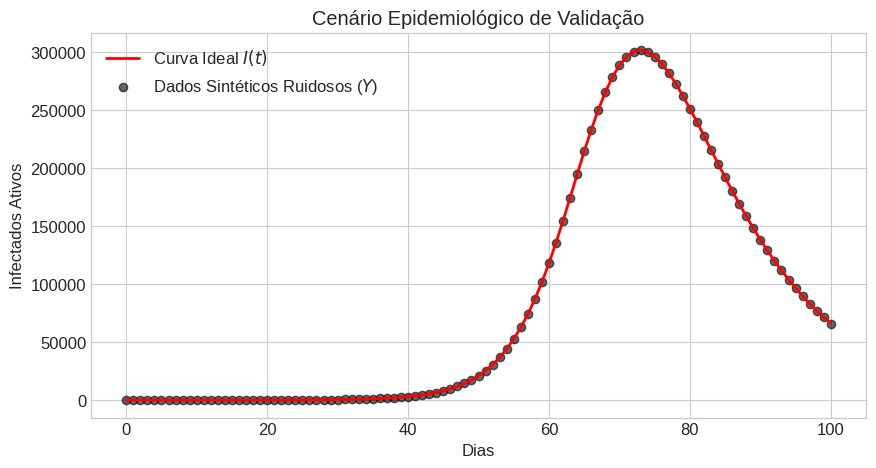

In [55]:
def plot_sint_X_real() :
  Y, I_real, eval_time = gaussian_noise(sigma=25.0)

  plt.figure()
  plt.plot(eval_time, I_real, 'r-', label='Curva Ideal $I(t)$', linewidth=2)
  plt.scatter(eval_time, Y, color='black', alpha=0.6, label='Dados Sintéticos Ruidosos ($Y$)')
  plt.title('Cenário Epidemiológico de Validação')
  plt.xlabel('Dias')
  plt.ylabel('Infectados Ativos')
  plt.legend()
  plt.savefig('dados_sinteticos.png', dpi=300, bbox_inches='tight') # Já salva a imagem para o LaTeX
  plt.show()

plot_sint_X_real()

## 4. O Importance Sampling

In [76]:
# distribuicao proposta q($\theta=(\beta,\gamma)$): uniforme bivariada
beta_min, beta_max = 0.1, 0.8
gamma_min, gamma_max = 0.01, 0.5

def importance_sampling(beta_min=0.1,
                        beta_max=0.8,
                        gamma_min=0.01,
                        gamma_max=0.5,
                        rounds=10_000, sigma=25.0) :


  beta_samples = np.random.uniform(beta_min, beta_max, rounds)
  gamma_samples = np.random.uniform(gamma_min, gamma_max, rounds)

  Y = gaussian_noise(sigma)

  log_w = np.zeros(rounds)

  print("Iniciando as simulações via Importance Sampling...")

  for i in tqdm(range(rounds), desc="Rodadas: "):
    beta_i = beta_samples[i]
    gamma_i = gamma_samples[i]

    I_candidate = ode_solver(N,
                        real_beta=beta_i,
                        real_gamma=gamma_i)

    # calcula a log-verossimilhança para evitar underflow numerico
    residual = Y - I_candidate
    log_w[i] = - (len(eval_time) / 2) * np.log(2 * np.pi * sigma**2) - np.sum(residual**2) / (2 * sigma**2)

  w = np.exp(log_w - np.max(log_w))
  W = w / np.sum(w)

  # estimadores finais via media ponderada
  hat_beta = np.sum(beta_samples * W)
  hat_gamma = np.sum(gamma_samples * W)

  print("Simulação concluída!")

  return hat_beta, hat_gamma, beta_samples, gamma_samples, W


## 5. Obtenção de métricas e resultados

In [77]:
def analytics() :
  hat_beta, hat_gamma, \
    beta_samples, gamma_samples, W = importance_sampling(beta_min,
                                                        beta_max,
                                                        gamma_min,
                                                        gamma_max)
  print("-" * 60)
  print("RELATORIO DE CONVERGENCIA DOS PARAMETROS")
  print("-" * 60)
  print(f"Beta Real:    {real_beta:.4f}  |  Beta Estimado:    {hat_beta:.4f}  | Erro: {abs(real_beta-hat_beta):.4f}")
  print(f"Gamma Real:   {real_gamma:.4f}  |  Gamma Estimado:   {hat_gamma:.4f}  | Erro: {abs(real_gamma-hat_gamma):.4f}")
  print(f"R_0 Real:     {real_beta/real_gamma:.4f}  |  R_0 Estimado:     {hat_beta/hat_gamma:.4f}  | Erro: {abs((real_beta/real_gamma)-(hat_beta/hat_gamma)):.4f}")
  print("-" * 60)

  return hat_beta, hat_gamma, \
    beta_samples, gamma_samples, W

In [78]:
hat_beta, hat_gamma, \
beta_samples, gamma_samples, W = analytics()

Iniciando as simulações via Importance Sampling...


Rodadas: 100%|██████████| 10000/10000 [00:32<00:00, 311.01it/s]

Simulação concluída!
------------------------------------------------------------
RELATORIO DE CONVERGENCIA DOS PARAMETROS
------------------------------------------------------------
Beta Real:    0.3000  |  Beta Estimado:    0.3402  | Erro: 0.0402
Gamma Real:   0.1000  |  Gamma Estimado:   0.1480  | Erro: 0.0480
R_0 Real:     3.0000  |  R_0 Estimado:     2.2994  | Erro: 0.7006
------------------------------------------------------------


## 6. Gráfico de dispersão (*scatter plot*) das amostras $\theta_i$ e dos estimadores $\hat{\theta}$ gerados

In [98]:
def scatter_plot() :
  plt.figure()
  scatter = plt.scatter(beta_samples, gamma_samples, c=W,
                       cmap='viridis', s=2, alpha=0.8)
  plt.colorbar(scatter, label='Peso de importância normalizado ($W_i$)')

  plt.scatter(real_beta, real_gamma, color='red', marker='X', s=150, label='Valor Real ($\\theta^*$)')
  plt.scatter(hat_beta, hat_gamma, color='cyan', marker='o', s=100, label='Valor Estimado ($\\hat{\\theta}$)')

  plt.title('Espaço de parâmetros amostrado pelo Importance Sampling')
  plt.xlabel('Taxa de Transmissão ($\\beta$)')
  plt.ylabel('Taxa de Recuperação ($\\gamma$)')
  plt.xlim(beta_min, beta_max)
  plt.ylim(gamma_min, gamma_max)

  plt.legend(loc='upper right',
             fontsize='small',
             frameon=True,
             facecolor='white',
             framealpha=0.99,
             edgecolor='gray')


  plt.savefig('convergencia_parametros.png', dpi=300, bbox_inches='tight')
  plt.show()

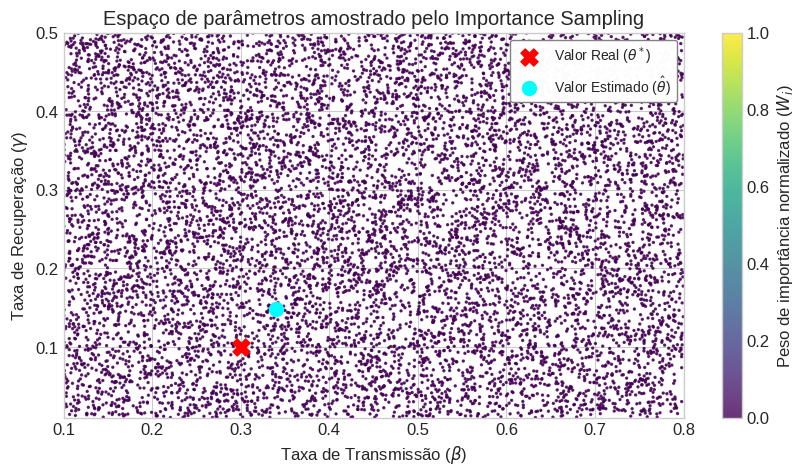

In [99]:
scatter_plot()

## 7. Cálculo da *Distância de Variação Total* ($d_{TV}$)

$$d_{TV}(\alpha, \beta) = \frac{1}{2} \sum_{k} \mid \alpha_k - \beta_k \mid$$

para medir a distância entre dois vetores $\alpha$ e $\beta$ quaisquer, $0 \leq d_{TV} \leq 1$. Para nosso exemplo, desejamos calcular $d_{TV}(\theta, \hat{\theta})$.


In [119]:
def total_variation(v1, v2) :
  try :
    assert len(v1) == len(v2)
  except AssertionError :
    print("Erro: vetores com dimensoes distintas!")

  acc = 0
  for k in range(len(v1)) :
    v2[k] = round(v2[k], 4)
    acc += abs(v1[k] - v2[k])

  d_TV = acc / 2
  print(f"v1 = ({v1})")
  print(f"v2 = ({v2})")
  print(f"\nDistancia de variacao total entre vetores: {d_TV:.4f}")

In [120]:
hat_theta = [hat_beta, hat_gamma]
theta = [real_beta, real_gamma]

total_variation(theta, hat_theta)

v1 = ([0.3, 0.1])
v2 = ([np.float64(0.3402), np.float64(0.148)])

Distancia de variacao total entre vetores: 0.0441
